In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

df = pd.read_csv('../data/processed/features.csv')

# Survival analysis cần: duration (tenure) + event (churn)
df_surv = df[['tenure', 'Churn_binary', 'Contract_encoded',
              'MonthlyCharges', 'InternetService_encoded',
              'SeniorCitizen', 'service_count',
              'charge_per_month', 'digital_engagement']].copy()

print(f"Shape: {df_surv.shape}")
print(f"Churn rate: {df_surv['Churn_binary'].mean():.3f}")
print(f"Avg tenure: {df_surv['tenure'].mean():.1f} months")

Shape: (7043, 9)
Churn rate: 0.265
Avg tenure: 32.4 months


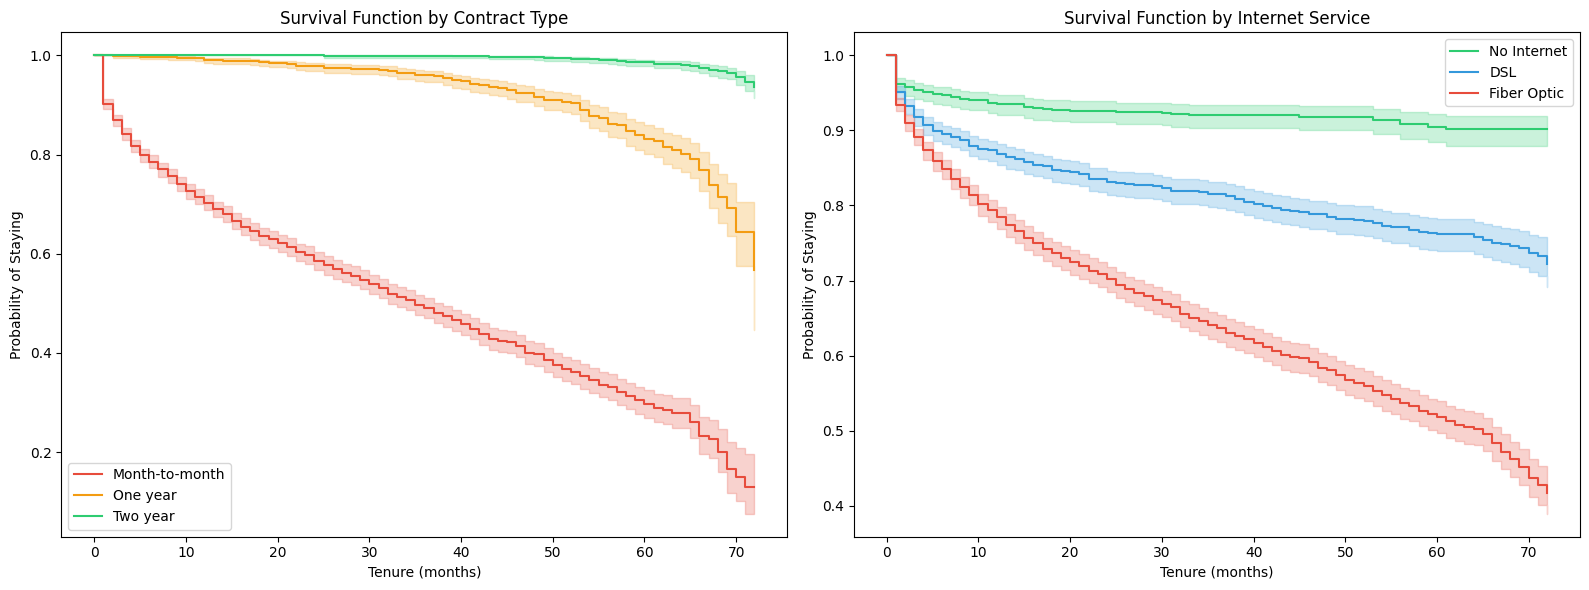

In [2]:
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KM by Contract type
ax = axes[0]
for contract, label, color in zip(
    [0, 1, 2],
    ['Month-to-month', 'One year', 'Two year'],
    ['#E74C3C', '#F39C12', '#2ECC71']
):
    mask = df_surv['Contract_encoded'] == contract
    kmf.fit(
        df_surv.loc[mask, 'tenure'],
        event_observed=df_surv.loc[mask, 'Churn_binary'],
        label=label
    )
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Survival Function by Contract Type')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Probability of Staying')
ax.legend()

# KM by Internet Service
ax = axes[1]
for service, label, color in zip(
    [0, 1, 2],
    ['No Internet', 'DSL', 'Fiber Optic'],
    ['#2ECC71', '#3498DB', '#E74C3C']
):
    mask = df_surv['InternetService_encoded'] == service
    kmf.fit(
        df_surv.loc[mask, 'tenure'],
        event_observed=df_surv.loc[mask, 'Churn_binary'],
        label=label
    )
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Survival Function by Internet Service')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Probability of Staying')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/km_curves.png', dpi=150)
plt.show()

In [3]:
print("=== LOG-RANK TEST: Contract Type ===")
groups = [df_surv[df_surv['Contract_encoded'] == i]['tenure'] for i in [0, 1, 2]]
events = [df_surv[df_surv['Contract_encoded'] == i]['Churn_binary'] for i in [0, 1, 2]]

result = logrank_test(groups[0], groups[1],
                       event_observed_A=events[0],
                       event_observed_B=events[1])
print(f"Month-to-month vs One year: p-value = {result.p_value:.6f}")

result2 = logrank_test(groups[0], groups[2],
                        event_observed_A=events[0],
                        event_observed_B=events[2])
print(f"Month-to-month vs Two year: p-value = {result2.p_value:.6f}")
print("p < 0.05 → Difference is statistically significant ✅" if result2.p_value < 0.05 else "Not significant")

=== LOG-RANK TEST: Contract Type ===
Month-to-month vs One year: p-value = 0.000000
Month-to-month vs Two year: p-value = 0.000000
p < 0.05 → Difference is statistically significant ✅


In [4]:
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    df_surv,
    duration_col='tenure',
    event_col='Churn_binary',
    show_progress=False
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn_binary'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13735.22
         time fit was run = 2026-03-09 15:14:05 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Contract_encoded        -0.85      0.43      0.03           -0.91           -0.79                0.40                0.46
MonthlyCharges           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
InternetService_encoded  0.27      1.31      0.04            0.20            0.34                1.22                1.41
SeniorCitizen            0.14      1.15      0.05            0.04            0.23                1.04                1.26
service_count           -0.16      0.85      0.01           -0.19           -0.14                0.83                0.87
charge_per_month         0.11      1.12      0.00            0.11            0.12                1.11                1.12
digital_engagement      -0.13      0.88      0.03           -0.19           -0.07                0.83                0.93

                         cmp to      z      p  -log2(p)
covariate                                              
Contract_encoded           0.00 -27.13 <0.005    535.90
MonthlyCharges             0.00   0.43   0.67      0.58
InternetService_encoded    0.00   7.53 <0.005     44.21
SeniorCitizen              0.00   2.82 <0.005      7.70
service_count              0.00 -12.59 <0.005    118.30
charge_per_month           0.00  42.87 <0.005       inf
digital_engagement         0.00  -4.24 <0.005     15.48
---
Concordance = 0.94
Partial AIC = 27484.44
log-likelihood ratio test = 3835.64 on 7 df
-log2(p) of ll-ratio test = inf

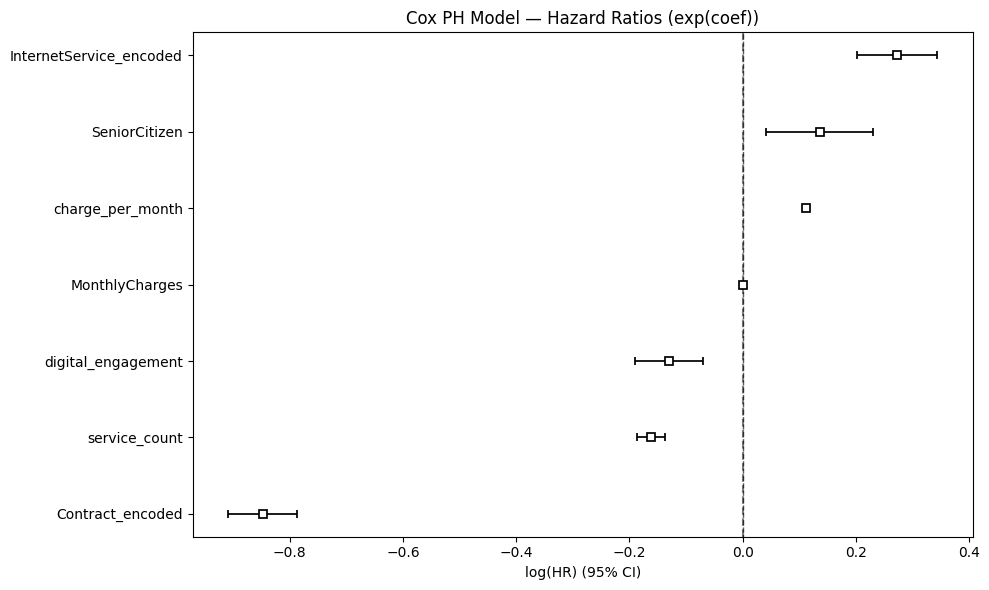


=== BUSINESS INTERPRETATION ===
Contract_encoded               HR=0.428 → GIẢM nguy cơ churn ⬇️ (p=0.0000)
InternetService_encoded        HR=1.314 → TĂNG nguy cơ churn ⬆️ (p=0.0000)
SeniorCitizen                  HR=1.146 → TĂNG nguy cơ churn ⬆️ (p=0.0048)
service_count                  HR=0.851 → GIẢM nguy cơ churn ⬇️ (p=0.0000)
charge_per_month               HR=1.119 → TĂNG nguy cơ churn ⬆️ (p=0.0000)
digital_engagement             HR=0.878 → GIẢM nguy cơ churn ⬇️ (p=0.0000)


In [5]:
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Cox PH Model — Hazard Ratios (exp(coef))')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/processed/cox_hazard_ratios.png', dpi=150)
plt.show()

print("\n=== BUSINESS INTERPRETATION ===")
summary = cph.summary
for feat in summary.index:
    hr = np.exp(summary.loc[feat, 'coef'])
    p = summary.loc[feat, 'p']
    direction = "TĂNG" if hr > 1 else "GIẢM"
    if p < 0.05:
        print(f"{feat:<30} HR={hr:.3f} → {direction} nguy cơ churn {'⬆️' if hr > 1 else '⬇️'} (p={p:.4f})")

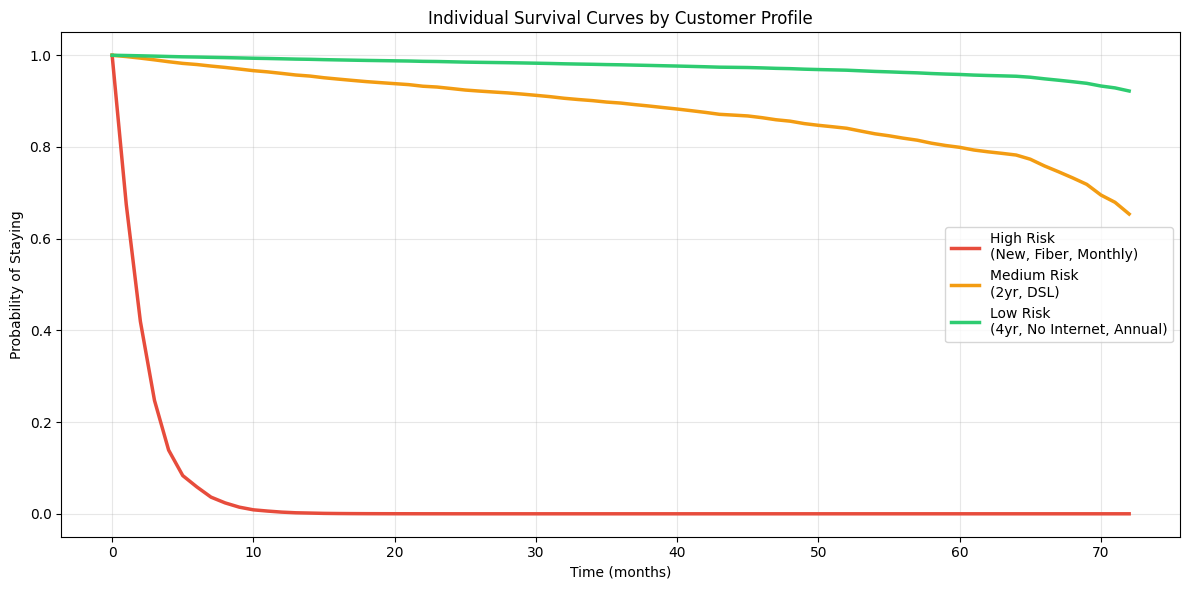

=== P(ACTIVE) TẠI CÁC MỐC THỜI GIAN ===
High Risk            t=  7 days → P(active) = 0.036
High Risk            t= 30 days → P(active) = 0.000
High Risk            t= 90 days → P(active) = 0.000

Medium Risk          t=  7 days → P(active) = 0.976
Medium Risk          t= 30 days → P(active) = 0.913
Medium Risk          t= 90 days → P(active) = 0.654

Low Risk             t=  7 days → P(active) = 0.995
Low Risk             t= 30 days → P(active) = 0.983
Low Risk             t= 90 days → P(active) = 0.922



In [6]:
# Predict survival curve cho 3 user profiles điển hình
profiles = pd.DataFrame({
    'tenure':                   [3,    24,   48],
    'Contract_encoded':         [0,    1,    2],
    'MonthlyCharges':           [95,   65,   45],
    'InternetService_encoded':  [2,    1,    0],
    'SeniorCitizen':            [0,    0,    0],
    'service_count':            [2,    5,    7],
    'charge_per_month':         [31,   2.7,  0.9],
    'digital_engagement':       [1,    2,    2],
})

profile_names = ['High Risk\n(New, Fiber, Monthly)',
                 'Medium Risk\n(2yr, DSL)',
                 'Low Risk\n(4yr, No Internet, Annual)']

colors = ['#E74C3C', '#F39C12', '#2ECC71']

plt.figure(figsize=(12, 6))
for i, (_, profile) in enumerate(profiles.iterrows()):
    surv = cph.predict_survival_function(profile.to_frame().T)
    plt.plot(surv.index, surv.values.flatten(),
             label=profile_names[i], color=colors[i], linewidth=2.5)

plt.xlabel('Time (months)')
plt.ylabel('Probability of Staying')
plt.title('Individual Survival Curves by Customer Profile')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/individual_survival_curves.png', dpi=150)
plt.show()

# Xác suất còn active tại các mốc thời gian
print("=== P(ACTIVE) TẠI CÁC MỐC THỜI GIAN ===")
for i, (_, profile) in enumerate(profiles.iterrows()):
    surv = cph.predict_survival_function(profile.to_frame().T)
    for t in [7, 30, 90]:
        idx = np.abs(surv.index - t).argmin()
        prob = surv.values.flatten()[idx]
        print(f"{profile_names[i].split(chr(10))[0]:<20} t={t:>3} days → P(active) = {prob:.3f}")
    print()

In [7]:
import joblib, os

c_index = concordance_index(
    df_surv['tenure'],
    -cph.predict_partial_hazard(df_surv),
    df_surv['Churn_binary']
)

print(f"=== SURVIVAL MODEL METRICS ===")
print(f"C-index: {c_index:.4f}")
print(f"(0.5 = random, 1.0 = perfect, >0.7 = good)")

# Save bằng joblib
os.makedirs('../data/processed/models', exist_ok=True)
joblib.dump(cph, '../data/processed/models/coxph_model.pkl')

import mlflow
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('churn-prediction')

with mlflow.start_run(run_name='coxph_survival'):
    mlflow.log_metric('c_index', c_index)
    mlflow.log_artifact('../data/processed/km_curves.png')
    mlflow.log_artifact('../data/processed/cox_hazard_ratios.png')
    mlflow.log_artifact('../data/processed/individual_survival_curves.png')

print("CoxPH model saved ✅")

=== SURVIVAL MODEL METRICS ===
C-index: 0.9415
(0.5 = random, 1.0 = perfect, >0.7 = good)
🏃 View run coxph_survival at: http://localhost:5000/#/experiments/1/runs/573f4939104c414cbcd0dc61633e63c6
🧪 View experiment at: http://localhost:5000/#/experiments/1


PermissionError: [Errno 13] Permission denied: '/mlflow'